In [1]:
import requests
import configparser
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from utils import plot_image, get_access_token
import numpy as np
from rasterio.io import MemoryFile
from datetime import datetime, timedelta
from sentinelhub import BBox, bbox_to_dimensions, CRS
from sentinelhub import SHConfig, SentinelHubCatalog, DataCollection
import evalscripts as eval
import pandas as pd
import os
import rasterio

/home/antonio/.pyenv/versions/3.8.5/envs/nitrates/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with rasterio.open(os.path.join("test_dir", "2022-07-04.tiff")) as dataset:
    bands = dataset.read()  # Multi-band array
    print(f"Dataset CRS: {dataset.crs}, Shape: {bands.shape}")

Dataset CRS: EPSG:4326, Shape: (13, 2183, 1271)


https://custom-scripts.sentinel-hub.com/sentinel-2/composites/

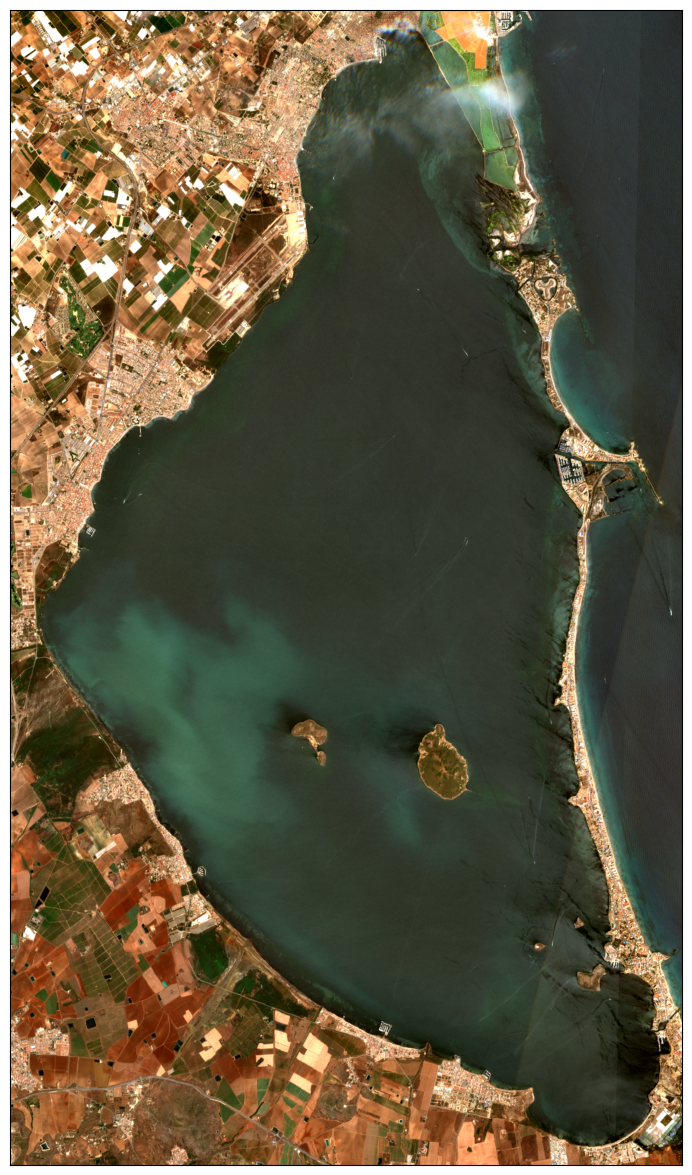

In [27]:
image = np.stack([bands[3],bands[2],bands[1]], axis=-1)

plot_image(image, factor=3 / 255, clip_range=(0, 1))
#plt.savefig("../saved_files/ImgSatelite_1.svg")

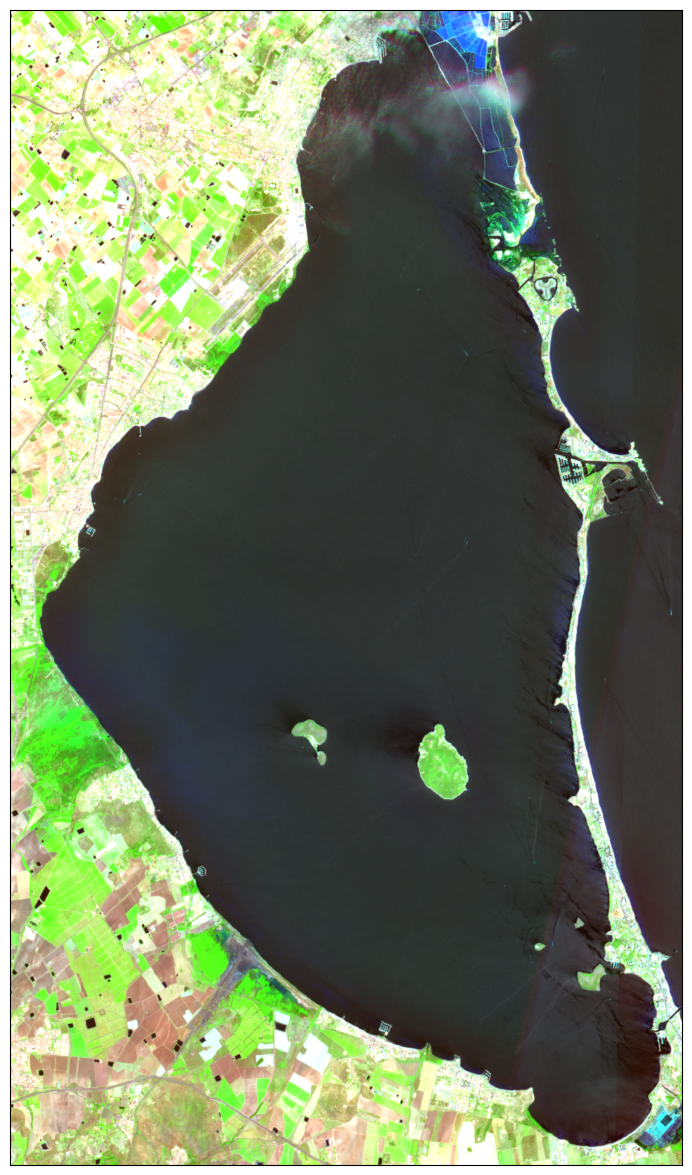

In [29]:
image = np.stack([bands[11],bands[7],bands[3]], axis=-1)

plot_image(image, factor=3 / 255, clip_range=(0, 1))
#plt.savefig("../saved_files/ImgSatelite_2.pdf")

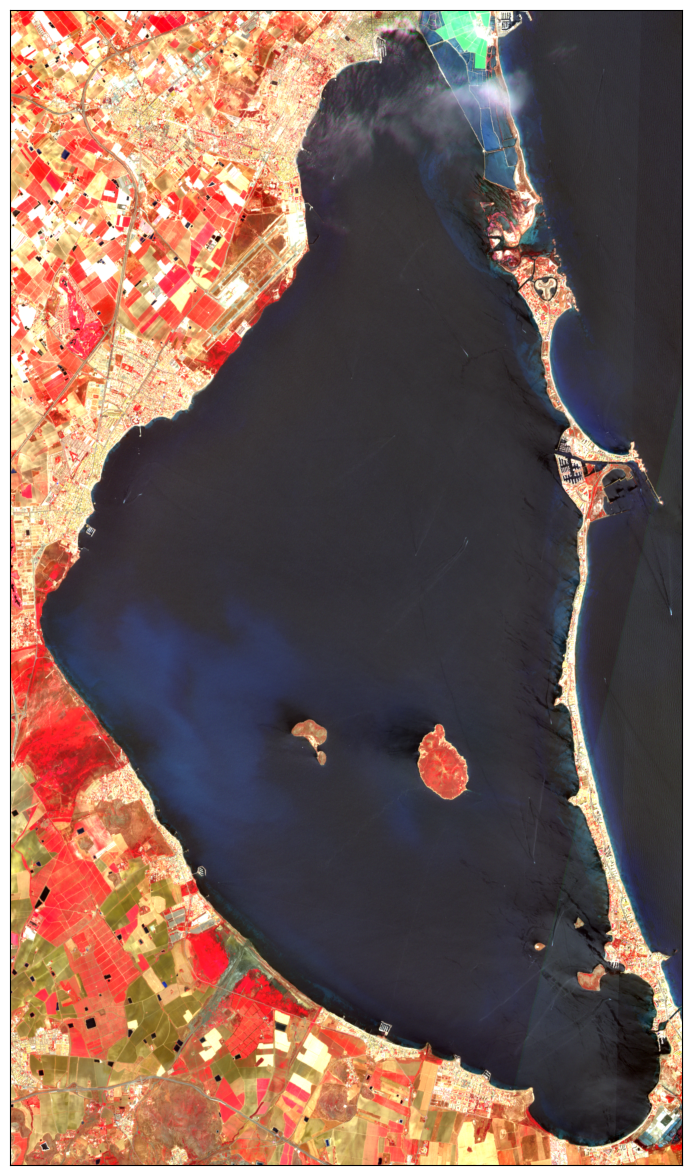

In [13]:
image = np.stack([bands[7],bands[3],bands[2]], axis=-1)

plot_image(image, factor=3 / 255, clip_range=(0, 1))

In [21]:
np.unique(ndwi_masked)

array([0.00275482, 0.00283286, 0.00286533, ..., 0.84615386, 1.        ,
              nan], dtype=float32)

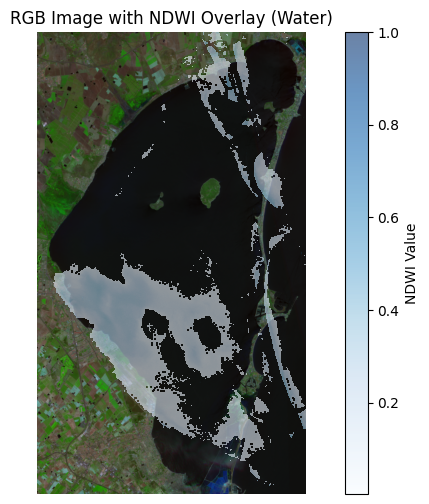

In [23]:
# Extract RGB (for visualization) and NDWI-related bands
rgb = np.stack([bands[11], bands[7], bands[3]], axis=-1)  # Example RGB Composite
rgb = rgb / np.max(rgb)  # Normalize RGB to [0, 1]

green = bands[2].astype(np.float32)  # Band 3 (index 2)
nir = bands[7].astype(np.float32)    # Band 8 (index 7)

# Compute NDWI
ndwi = (green - nir) / (green + nir + 1e-10)  # Avoid division by zero

# Create NDWI mask: Keep only NDWI > 0
ndwi_masked = np.where(ndwi > 0, ndwi, np.nan)

# Plot RGB background
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(rgb, extent=[0, rgb.shape[1], 0, rgb.shape[0]])  # RGB Image

# Overlay NDWI where NDWI > 0
ndwi_plot = ax.imshow(ndwi_masked, cmap='Blues', alpha=0.6)  # Transparency for blending

# Add colorbar and labels
plt.colorbar(ndwi_plot, ax=ax, label="NDWI Value")
plt.title("RGB Image with NDWI Overlay (Water)")
plt.axis("off")

plt.show()

